In [1]:
import sys
MODULEPATH="../../"
sys.path.append(MODULEPATH)
sys.path.append('../')

from connectivity.connectivity import trace_connectivity, extract_connection_indices, save_descent_paths
from connectivity.plot_results import plot_results_with_paths, plot_saddle_tree_with_function
from test_schwefel.schwefel_function_nnmodule import Schwefel2D, schwefel_loss, schwefel2D_numpy
from connectivity.connectivity import optimize_lbfgs

from connectivity.saddle_tree_calculations import saddle_tree_calculations
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
critical_points_file = "./critical_points_schwefel_torch.csv"

outdir = './results/'

dataframe = pd.read_csv(critical_points_file, index_col=0)
no_maxima = dataframe["type"]!="maximum"
dataframe = dataframe[no_maxima]

saddles_df = dataframe[dataframe["type"] == "saddle"]
minima_df = dataframe[dataframe["type"] == "minimum"]
# minima_df = dataframe[dataframe["type"] != "maximum"]

build_schwefel = lambda p: Schwefel2D(*p)

print(dataframe)

          x1        x2   f_value     type  index
0   0.824375  0.341809 -0.201843  minimum      0
1   0.824375  0.034551 -0.063635  minimum      0
2   0.034551  0.341809  0.153505  minimum      0
3   0.824375  0.824375 -0.418983  minimum      0
4   0.341810  0.824375 -0.201843  minimum      0
5   0.341809  0.341809  0.015296  minimum      0
6   0.034551  0.034551  0.291713  minimum      0
7   0.341809  0.034551  0.153505  minimum      0
8   0.034551  0.824375 -0.063635  minimum      0
13  0.561167  0.824375  0.300545   saddle      1
14  0.166287  0.034551  0.478224   saddle      1
15  0.034551  0.561166  0.655892   saddle      1
16  0.561166  0.341810  0.517684   saddle      1
17  0.341810  0.561167  0.517684   saddle      1
18  0.166288  0.824375  0.122876   saddle      1
19  0.824375  0.561167  0.300545   saddle      1
20  0.341810  0.166288  0.340016   saddle      1
21  0.824375  0.166287  0.122876   saddle      1
22  0.561167  0.034551  0.655892   saddle      1
23  0.166287  0.3418

In [3]:
all_results, minima, dataframe, paths = trace_connectivity(saddles_df,
                                                           minima_df,
                                                           dataframe,
                                                           schwefel_loss,
                                                           build_schwefel,
                                                           [],
                                                           return_paths=True)


In [4]:
save_descent_paths(paths, out_dir=outdir+'descent_paths/')
extract_connection_indices(all_results, dataframe, out_dir=outdir)
saddle_tree_calculations(all_results, minima, dataframe, out_dir=outdir)

connectivity_df=pd.read_csv(outdir+"/connectivity_graph.csv")

Saved 24 connections to ./results//connectivity_graph.csv
Saved node order to ./results/tree_nodes.csv
Saved tree edges to ./results/tree_connectivity.csv


/tmp/ipykernel_230534/3201057130.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()


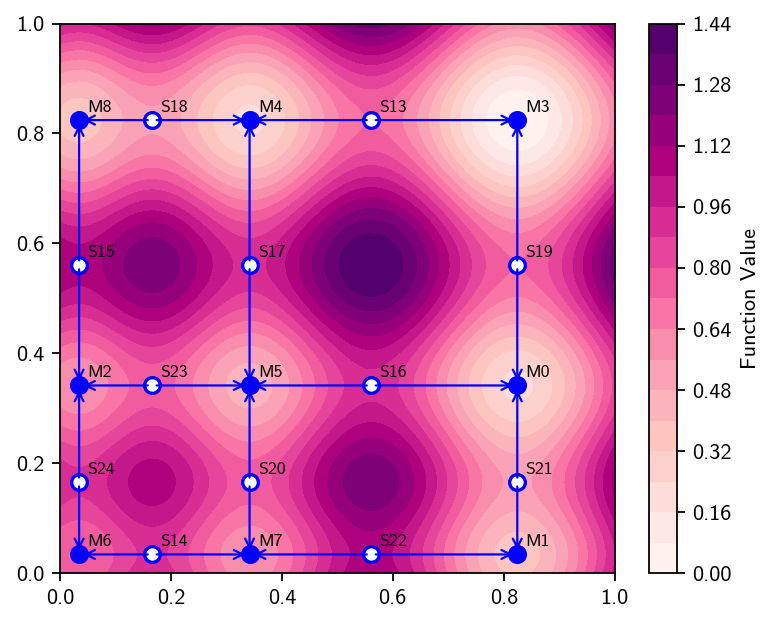

In [5]:

fig2 = plt.figure(figsize=(5,4), dpi=160)
fig2 = plot_results_with_paths(func=schwefel2D_numpy,  
                                critical_points_df=dataframe,
                                connectivity_df=connectivity_df, 
                                bounds=(0, 1),
                                res=200,
                                fig=fig2
)
fig2.show()
fig2.savefig(outdir+"/landscape_paths.png")  # Optional

/tmp/ipykernel_230534/917065622.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()


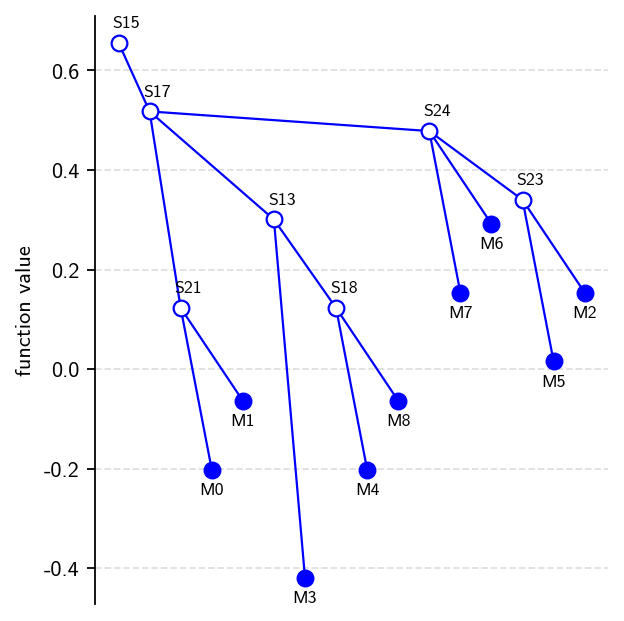

In [6]:
fig1 = plt.figure(figsize=(4,4), dpi=160)
fig1 = plot_saddle_tree_with_function(dataframe, 
                                      nodes_csv=outdir+"/tree_nodes.csv",
                                      edges_csv=outdir+"/tree_connectivity.csv", 
                                      fig=fig1,
                                      txt_pads=(5e-1, 4e-2))

ax = fig1.axes[0]
ax.set_ylabel("function value")
# ax.yaxis.set_major_locator(MaxNLocator(10))
fig1.tight_layout()

fig1.show()
fig1.savefig(outdir+"/tree_plot.png")  # Optional